In [8]:
import subprocess, sys

libs = [
    "torch torchvision --index-url https://download.pytorch.org/whl/cu118",
    "diffusers",
    "transformers",
    "accelerate",
    "xformers",
    "Pillow"
]

for lib in libs:
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + lib.split() + ["-q"])

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xformers 0.0.35 requires torch>=2.10, but you have torch 2.7.1+cu118 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.22.1+cu118 requires torch==2.7.1, but you have torch 2.11.0 which is incompatible.


In [2]:
import torch
import multiprocessing

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device == "cuda" else torch.float32

if device == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    torch.set_num_threads(multiprocessing.cpu_count())
    print(f"CPU : {multiprocessing.cpu_count()} threads")
    print("CPU mode — generation ~10-15 min")

print(f"dtype: {dtype}")

GPU : NVIDIA GeForce RTX 3060
VRAM: 12.5 GB
dtype: torch.float16


In [3]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True
)

pipe = pipe.to(device)

if device == "cuda":
    pipe.enable_attention_slicing(1)
    try:
        pipe.enable_xformers_memory_efficient_attention()
        print("xformers: enabled")
    except Exception:
        print("xformers: not available")

print("Model ready")

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.43it/s]


xformers: not available
Model ready


  0%|          | 0/25 [00:00<?, ?it/s]/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 25/25 [00:05<00:00,  4.99it/s]


Saved: movsar_sd_20260416_104913.png


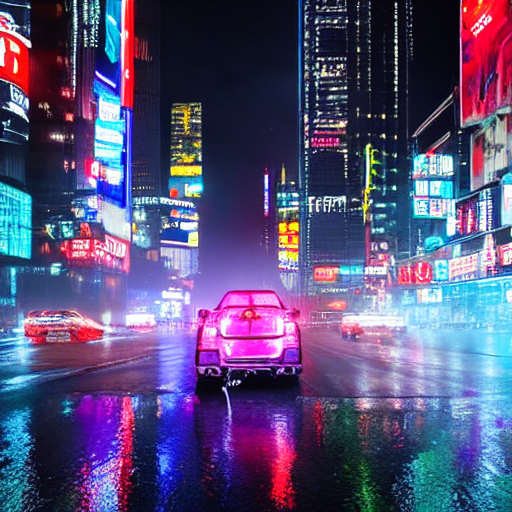

In [ ]:
from datetime import datetime

prompt = (
    "A sprawling cyberpunk megacity at midnight, rain-slicked streets reflecting "
    "cascades of neon signs in Cyrillic and Japanese, towering brutalist skyscrapers "
    "wrapped in holographic banners, hovercars threading between lit windows, "
    "volumetric fog, ultra-detailed, cinematic 4k, photorealistic render"
)

negative_prompt = (
    "daytime, sunny, cartoon, anime, low quality, blurry, watermark, "
    "text overlay, deformed architecture, oversaturated"
)

seed = 2077
generator = torch.Generator(device=device).manual_seed(seed)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=25,
    guidance_scale=7.5,
    width=512,
    height=512,
    generator=generator
)

image = result.images[0]
filename = f"m_sd_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
image.save(filename)
print(f"Saved: {filename}")
image